# Other Simulation Codes — Worked Examples

!!! note "Executed notebook"
    This page loads PLUTO / Chombo / Athena++ / FLASH / GADGET and the AREPO/IllustrisTNG
    gas workflow end-to-end — real snapshots, real outputs. See
    [Multi-code support](multicode.md) for the overview and the per-code reader pages.

Mera began as a RAMSES tool, but its analysis layer is **code-blind** — it works on a generic
uniform/AMR cell list (or particle list), not on RAMSES file formats. So the *same* calls
(`getvar`, `projection`, `subregion`, `timeseries`, `savedata`, …) run on data from several codes:

| Code | grid / particles | what this notebook shows |
|---|---|---|
| **PLUTO** (uniform + Chombo-AMR) | grid | load, getvar |
| **Athena++** | AMR grid + MHD | MHD field, load-time sub-region |
| **FLASH** | AMR grid | a self-gravity potential field |
| **GADGET** (+ GIZMO/AREPO/SWIFT/TNG) | particles + **gas cells** | `getparticles`, gas ρ/T/Z, SPH maps |

It also covers self-gravity, chemistry and radiative-transfer fields, and converting any code to a
Mera file. See the [Multi-code support](https://manuelbehrendt.github.io/Mera.jl/stable/multicode/)
docs for the full reference.

> The test snapshots live under `MERA_TEST_DATA` (download the synthetic/sample data, or point the
> path at your own runs).

In [1]:
using Mera
base = get(ENV, "MERA_TEST_DATA", "/Volumes/FASTStorage/Simulations/Mera-Tests")


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0



"/Volumes/FASTStorage/Simulations/Mera-Tests"

## PLUTO (uniform grid)

`getinfo` auto-detects the code from the directory's signature files and prints the same overview a
RAMSES snapshot would; `gethydro` then returns an ordinary `HydroDataType`.

In [2]:
info = getinfo(5, joinpath(base, "PLUTO/pluto_sedov3d"))   # auto-detects PLUTO
gas  = gethydro(info, verbose=false)
maximum(getvar(gas, :rho))                           # the usual analysis, unchanged

[Mera]: 2026-07-31T14:30:59.279



Code: PLUTO
output: 5  time: 0.5 [code units]
grid: 64³ uniform Cartesian, level 6, boxlen = 1.0
variables: (rho, vx, vy, vz, p)
-------------------------------------------------------


4.040484204505616

## Chombo (PLUTO-AMR)

PLUTO's AMR output (the Chombo HDF5 format) loads as a Mera **AMR** object with a `:level` column.

In [3]:
gc = gethydro(getinfo(0, joinpath(base, "CHOMBO/chombo_3d/IsothermalSphere"), verbose=false), verbose=false)
sort(unique(getvar(gc, :level)))                # the refinement levels present

2-element Vector{Float64}:
 6.0
 7.0

## Athena++ (AMR MHD) + a load-time sub-region

Athena++ `.athdf` snapshots carry cell-centred MHD, so `:bx/:by/:bz` and derived `:bmag` work. The
spatial-window arguments load only part of the box (reading only the intersecting MeshBlocks).

In [4]:
ia = getinfo(5, joinpath(base, "ATHENA/athena_blast"))       # a self-built 3-D MHD blast
ga = gethydro(ia, verbose=false)
@show maximum(getvar(ga, :bmag));                    # magnetic field strength

# central 20% box — only the intersecting blocks are read
gsub = gethydro(ia; xrange=[-0.1,0.1], yrange=[-0.1,0.1], zrange=[-0.1,0.1],
                center=[:bc], range_unit=:standard, verbose=false)
length(gsub.data), length(ga.data)                   # sub-region ≪ full snapshot

[Mera]: 2026-07-31T14:31:11.610



Code: Athena++
output: 5  time: 0.50111 [code units]
root grid: 32³ (level 5), MaxLevel 2 ⇒ levels 5:7, boxlen = 2.0
MeshBlocks: 148   variables: (rho, p, vx, vy, vz, bx, by, bz)
-------------------------------------------------------
maximum(getvar(ga, :bmag)) = 1.1211309571451635

(17576, 606208)

## FLASH

FLASH plot files load as AMR hydro/MHD; a self-gravity potential (if present) appears as `:gpot`.

In [5]:
gf = gethydro(getinfo(150, joinpath(base, "FLASH/flash_gassloshing/GasSloshing"), verbose=false), verbose=false)
:gpot in gf.info.variable_list

true

## GADGET / GIZMO / AREPO / SWIFT / IllustrisTNG (particles)

GADGET HDF5 is particle-based, so it loads through `getparticles` into a `PartDataType`. `:family`
is the particle type (0 gas, 1 DM, 2 disk, 3 bulge, 4 stars, 5 BH); `families=` selects a subset.

In [6]:
ig = getinfo(200, joinpath(base, "GADGET/gadget_diskgalaxy/GadgetDiskGalaxy"))
stars = getparticles_gadget(ig; families=[4])        # just the star particles
length(stars.data), msum(stars) > 0

[Mera]: 2026-07-31T14:31:35.870



Code: GADGET
output: 200  time: 0.34483  redshift: 1.9
boxlen = 64000.0
particles: 4334546 gas, 4786616 halo/DM, 2333848 disk, 450921 stars, 1149 bndry/BH  (total 11907080)
-------------------------------------------------------
[Mera]: GADGET

 particles = 450921, families 4  (x,y,z,vx,vy,vz,mass,id,family)


(450921, true)

### AREPO / IllustrisTNG — gas-cell physics

For **gas** (`PartType0`) the Voronoi-cell fields are read too, so the full thermodynamic analysis
runs in **physical units** (comoving→physical *a*/*h* is applied automatically for cosmological
runs). Below: a real IllustrisTNG halo cutout.

In [7]:
it  = getinfo(59, joinpath(base, "AREPO/TNGHalo/TNGHalo/halo_59.hdf5"))   # IllustrisTNG (AREPO)
gas = getparticles_gadget(it; families=[0])      # PartType0 gas → :rho,:u,:ne,:metallicity,:sfr,:volume + :T
println("gas cells   : ", length(gas.data))
println("rho [g/cm³] : ", extrema(getvar(gas, :rho, :g_cm3)))
println("T   [K]     : ", extrema(getvar(gas, :T, :K)))
println("metallicity : ", extrema(getvar(gas, :metallicity)))

[Mera]: 2026-07-31T14:31:39.439



Code: AREPO
output: 59  time: 1.0  redshift: 0.0
boxlen = 205000.0
particles: 4006794 gas, 5567314 halo/DM, 533034 stars  (total 10107142)
-------------------------------------------------------
[Mera]: AREPO

 gas cells = 4006794, families 0  (x,y,z,vx,vy,vz,mass,id,family,rho,u,ne,metallicity,sfr,nh,mach,gpot,bx,by,bz,volume)
gas cells   : 4006794
rho [g/cm³] : 

(1.3854807197342735e-30, 1.17827292777639e-22)
T   [K]     : 

(17.965557996942838, 1.2925814640761332e8)
metallicity : (8.100937520794105e-8, 0.04447760060429573)


In [8]:
# the usual reductions run unchanged on AREPO gas, in physical units
n = length(gas.data)
println("median T [K]   : ", sort(getvar(gas, :T, :K))[n ÷ 2])
println("median Z       : ", sort(getvar(gas, :metallicity))[n ÷ 2])
println("gas mass [Msol]: ", msum(gas, :Msol))

median T [K]   : 1.436872560859919e7
median Z       : 

0.001993876649066806
gas mass [Msol]: 4.6930995577059625e13


### Magnetic fields (MHD)

IllustrisTNG is a **magneto**-hydrodynamic run, so its gas carries a `MagneticField`. Mera reads it
into `:bx`/`:by`/`:bz` (physical Gauss; comoving→physical *a⁻²* applied), and `getvar` derives the
usual magnetic quantities — `:bmag` (|B|), `:pmag` (B²/2), plasma `:beta`, Alfvén speed `:v_alfven`,
and the magnetosonic Mach numbers — exactly as for a native RAMSES-MHD run (and they project into
maps like any other field). Below: the **B–ρ relation** (flux freezing, |B| rising with density) and
how the field strength varies across thermal phases, on the real TNG halo gas.

In [9]:
# the magnetic field is read in physical units; getvar derives |B|, β, v_A, … on the gas
nB = length(gas.data)
println("|B|  [μG]       : ", round.(extrema(getvar(gas, :bmag, :muG)), sigdigits=3))
println("median |B| [μG] : ", round(sort(getvar(gas, :bmag, :muG))[nB ÷ 2], sigdigits=3))
println("plasma β        : median ", round(sort(getvar(gas, :beta))[nB ÷ 2], sigdigits=3), "  (≫1 ⇒ thermal-dominated)")
println("v_Alfvén [km/s] : median ", round(sort(getvar(gas, :v_alfven, :km_s))[nB ÷ 2], sigdigits=3))

|B|  [μG]       : (9.88e-7, 357.0)
median |B| [μG] : 0.243


plasma β        : median 

201.0  (≫1 ⇒ thermal-dominated)
v_Alfvén [km/s] : median 43.0


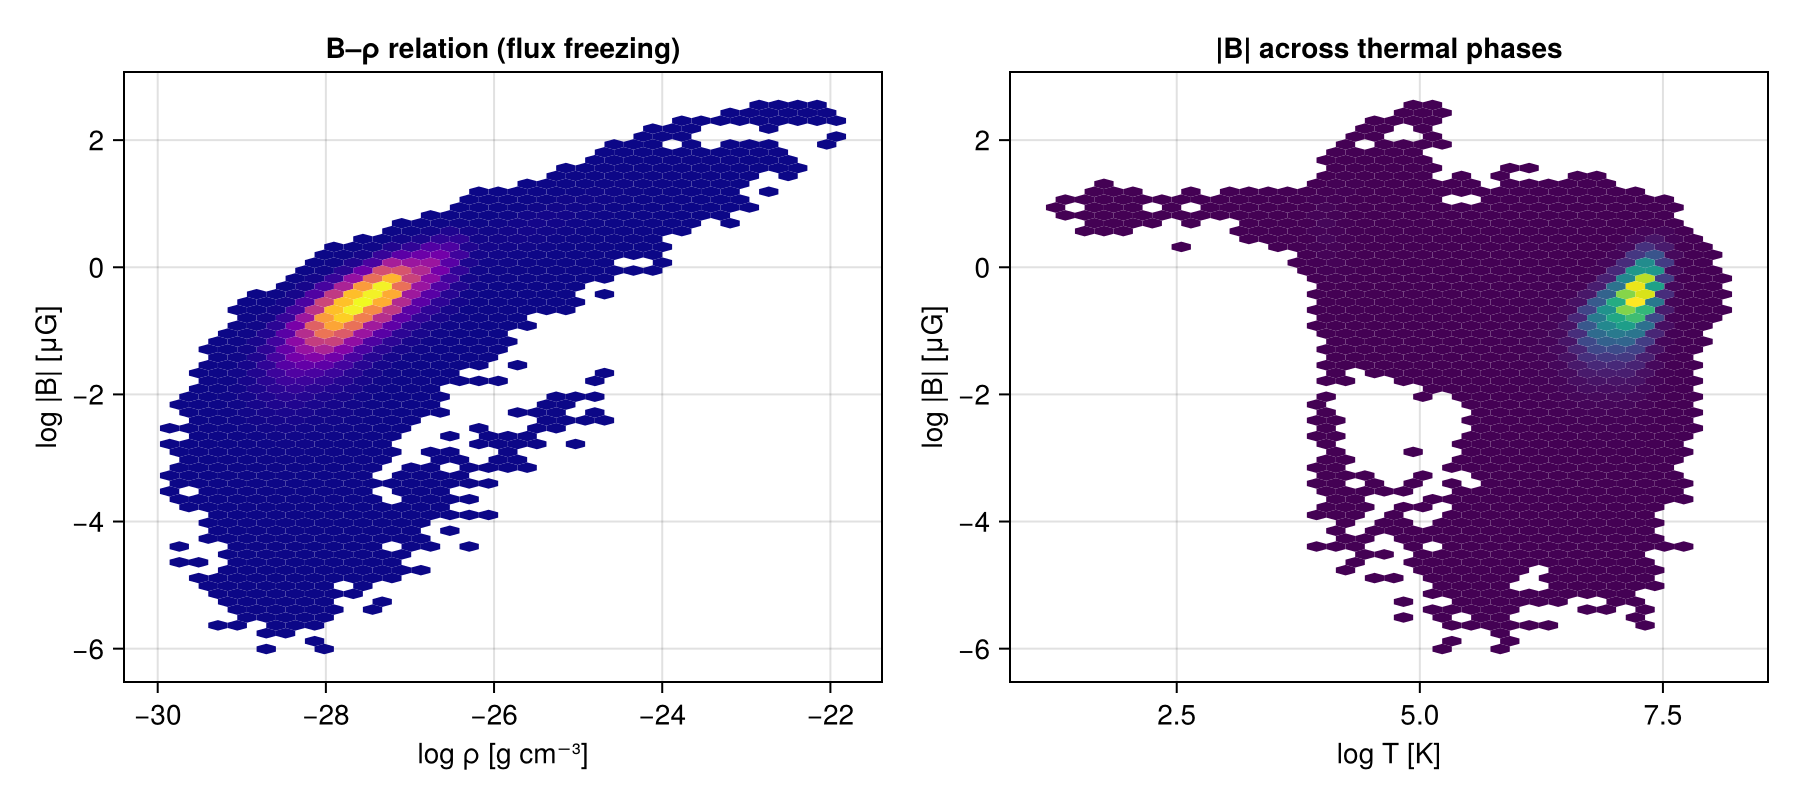

In [10]:
using CairoMakie, Statistics
ρ = getvar(gas, :rho, :g_cm3);  Bμ = getvar(gas, :bmag, :muG);  T = getvar(gas, :T, :K)
ok = (ρ .> 0) .& (Bμ .> 0) .& (T .> 0)
figB = Figure(size=(900, 400))
a1 = Axis(figB[1,1]; title="B–ρ relation (flux freezing)", xlabel="log ρ [g cm⁻³]", ylabel="log |B| [μG]")
hexbin!(a1, log10.(ρ[ok]), log10.(Bμ[ok]); bins=70, colormap=:plasma)
a2 = Axis(figB[1,2]; title="|B| across thermal phases",   xlabel="log T [K]",       ylabel="log |B| [μG]")
hexbin!(a2, log10.(T[ok]), log10.(Bμ[ok]); bins=70, colormap=:viridis)
figB

### Box-filling maps — a full AREPO volume

The TNGHalo above is a halo *cutout*, so its gas is centrally concentrated. For maps that **fill the
frame**, here is `ArepoBullet` — a full AREPO **cluster-merger box** (non-cosmological) whose gas fills
the whole volume. Surface density and mass-weighted temperature (SPH kernel).

[Mera]: 2026-07-31T14:31:58.940



Code: AREPO
output: 150  time: 1.5381  redshift: 0.0
boxlen = 40000.0
particles: 12865831 gas, 13368238 halo/DM, 295531 stars  (total 26529600)
-------------------------------------------------------
[Mera]: AREPO

 gas cells = 12865831, families 0  (x,y,z,vx,vy,vz,mass,id,family,rho,u,gpot,volume)
[Mera]: 2026-07-31T14:32:03.127



center: [0.5, 0.5, 0.5] ==> [19.999 [Mpc] :: 19.999 [Mpc] :: 19.999 [Mpc]]

domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]

Effective resolution: 256^2


Pixel size: 156.246 [kpc]
Simulation min.: 19.999 [Mpc]

[Mera]: 2026-07-31T14:32:50.124



center: [0.5, 0.5, 0.5] ==> [19.999 [Mpc] :: 19.999 [Mpc] :: 19.999 [Mpc]]

domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]

Effective resolution: 256^2
Pixel size: 156.246 [kpc]
Simulation min.: 19.999 [Mpc]



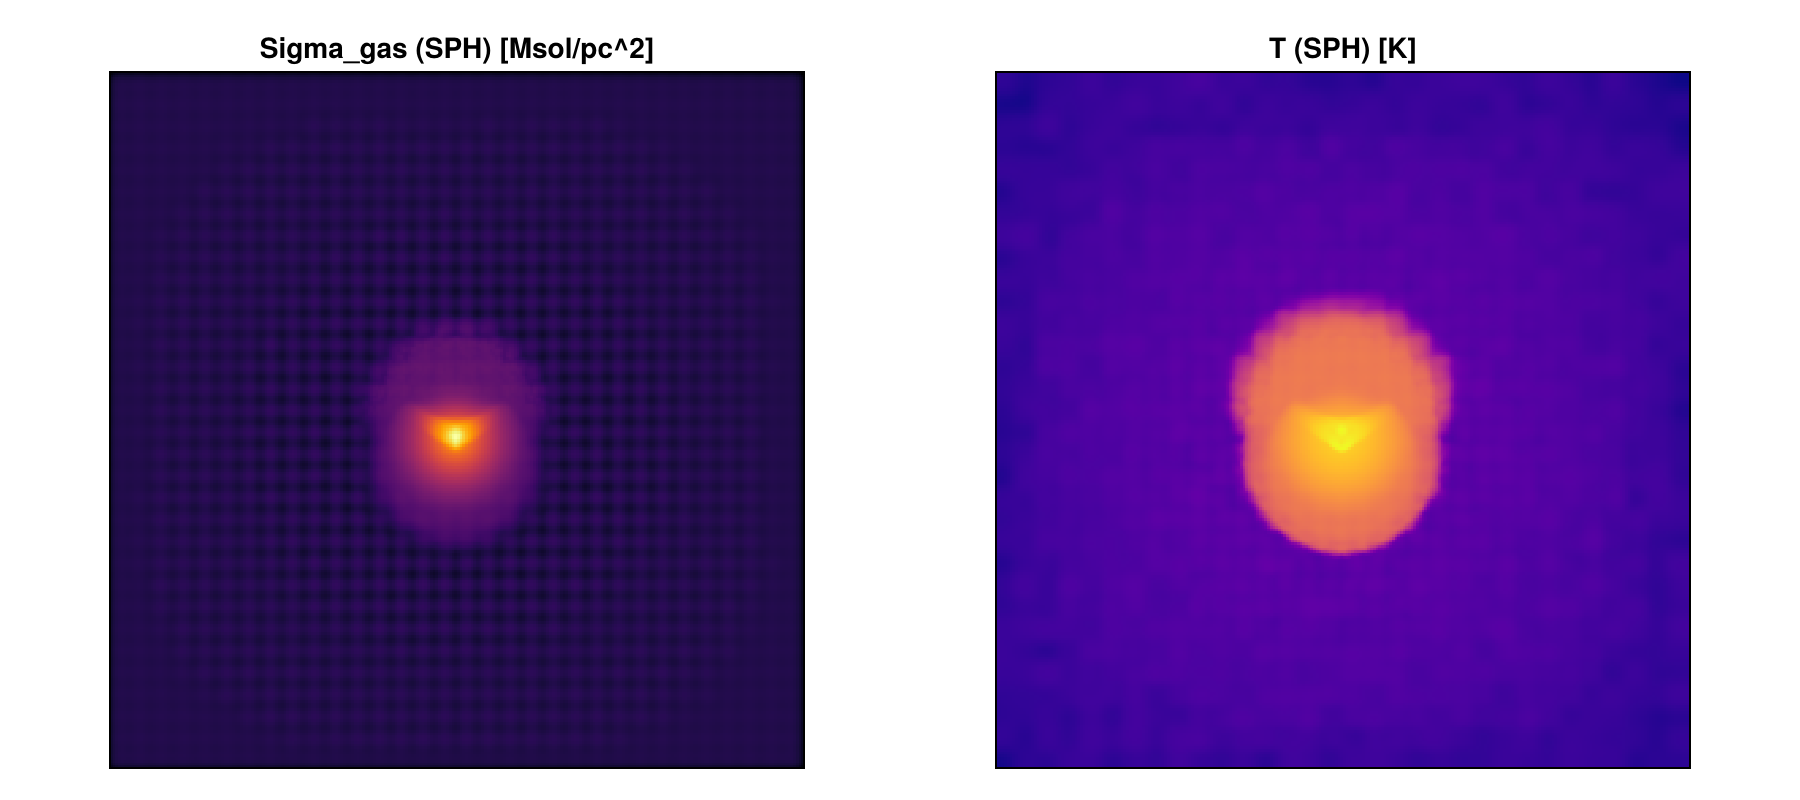

In [11]:
using CairoMakie, Statistics
ib   = getinfo(150, joinpath(base, "AREPO/ArepoBullet/ArepoBullet/snapshot_150.hdf5"))  # AREPO cluster-merger box
bgas = getparticles_gadget(ib; families=[0])
sd = projection(bgas, :sd, :Msol_pc2, res=256, center=[:bc], weighting=:sph)   # fills the frame
Tm = projection(bgas, :T,             res=256, center=[:bc], weighting=:sph)
fig = Figure(size=(900, 400))
a1 = Axis(fig[1,1]; title="Sigma_gas (SPH) [Msol/pc^2]", aspect=DataAspect()); hidedecorations!(a1)
a2 = Axis(fig[1,2]; title="T (SPH) [K]",                  aspect=DataAspect()); hidedecorations!(a2)
heatmap!(a1, log10.(ifelse.(sd.maps[:sd] .> 0, sd.maps[:sd], NaN))'; colormap=:inferno)
heatmap!(a2, log10.(ifelse.(Tm.maps[:T]  .> 0, Tm.maps[:T],  NaN))'; colormap=:plasma)
fig

**SPH vs Voronoi** on the same box-filling run: `weighting=:sph` (smooth, isotropic kernel — the
conserving default) vs `weighting=:voronoi` (nearest-generator — sharp, showing the moving-mesh cells).

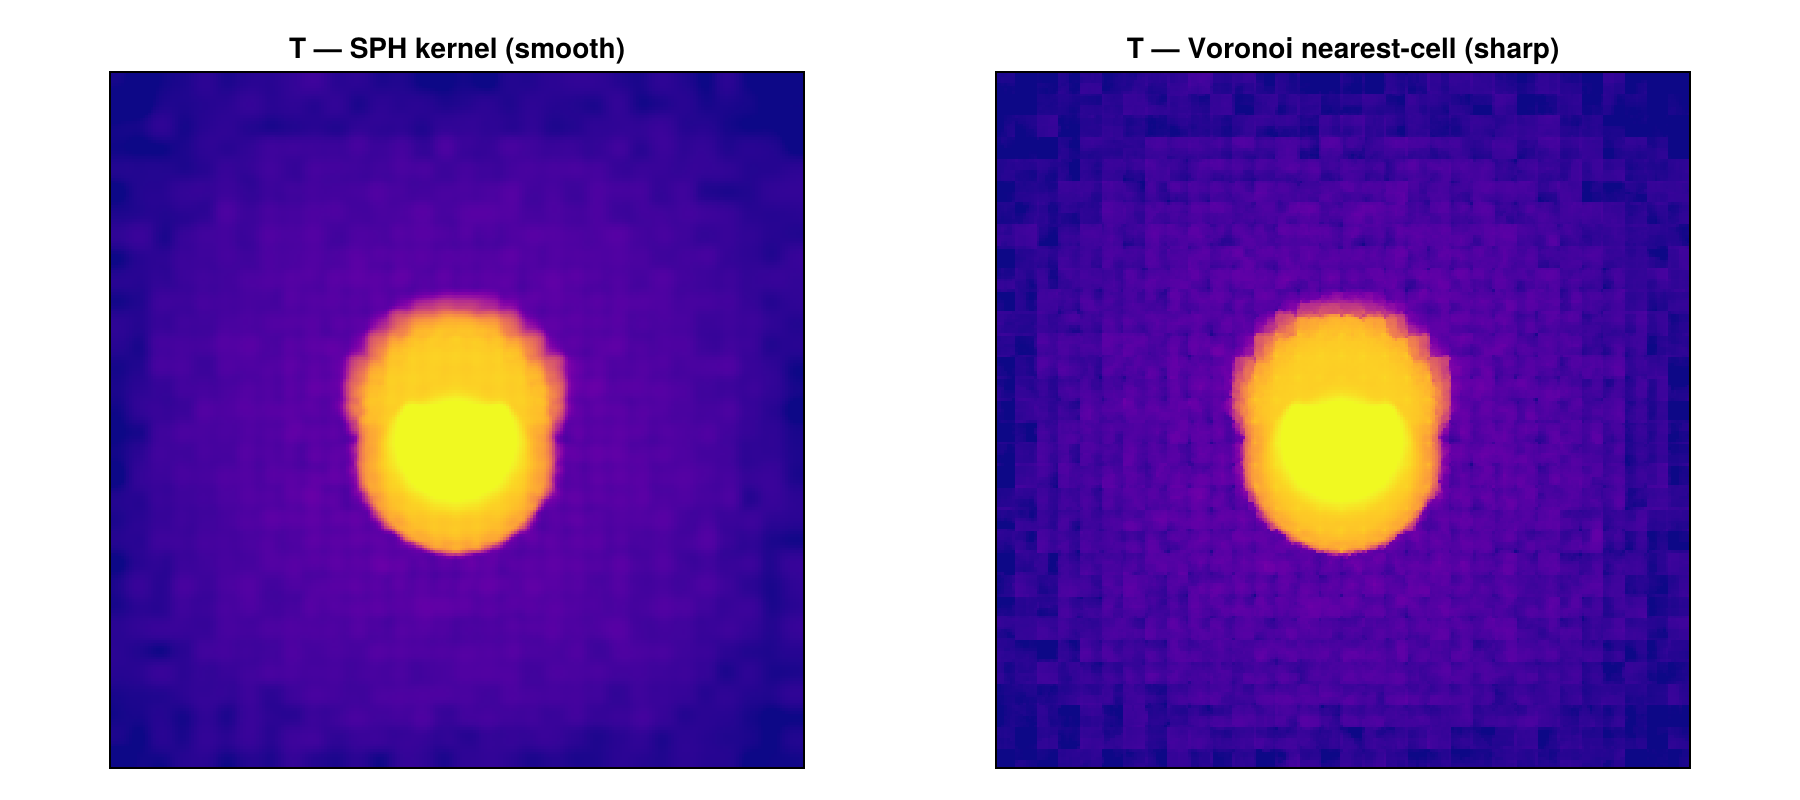

In [12]:
Ts = projection(bgas, :T; res=256, center=[:bc], weighting=:sph,     verbose=false, show_progress=false)
Tv = projection(bgas, :T; res=256, center=[:bc], weighting=:voronoi, verbose=false, show_progress=false)
cr = Tuple(quantile(log10.(filter(>(0), Ts.maps[:T])), [0.02, 0.98]))     # shared colour scale
fig2 = Figure(size=(900, 400))
b1 = Axis(fig2[1,1]; title="T — SPH kernel (smooth)",          aspect=DataAspect()); hidedecorations!(b1)
b2 = Axis(fig2[1,2]; title="T — Voronoi nearest-cell (sharp)", aspect=DataAspect()); hidedecorations!(b2)
heatmap!(b1, log10.(ifelse.(Ts.maps[:T] .> 0, Ts.maps[:T], NaN))'; colormap=:plasma, colorrange=cr)
heatmap!(b2, log10.(ifelse.(Tv.maps[:T] .> 0, Tv.maps[:T], NaN))'; colormap=:plasma, colorrange=cr)
fig2

### Multi-file snapshots, column selection, and the Voronoi tessellation

Production AREPO runs split one snapshot across many files (`snapdir_NNN/snap_NNN.0.hdf5 …`). Mera
resolves the set and streams it chunk by chunk — nothing extra to pass. Two properties of real
chunked data matter, and neither can be reproduced by a single-file sample:

- a particle type may be **absent from chunk 0**, so field discovery scans forward for a chunk that
  carries it (the same thing `illustris_python` does);
- particle counts above 2³² are split across `NumPart_Total` and `NumPart_Total_HighWord`.

Below, a 16-chunk CAMELS zoom at *z* = 4. It also shows `vars=` — which limits *which* gas columns
are read, usually the dominant memory cost — and the invariant that makes a moving mesh different
from an AMR grid: **the Voronoi cells tile space exactly**, so their volumes sum to the box volume.


In [13]:
capath = joinpath(base, "AREPO/camels_GZ28_499/snapdir_024")
if isdir(capath)
    ci = getinfo(24, capath)                       # 16 chunks, resolved automatically
    println("chunks found : ", length(Mera._gadget_files(24, capath)))
    println("z = ", round(1/ci.aexp - 1, digits=3), "   h = ", round(ci.H0/100, digits=4))

    # `vars=` selects which STORED gas columns are read; the 9 base columns always load
    win = (families=[0], xrange=[0.48,0.52], yrange=[0.48,0.52], zrange=[0.48,0.52],
           center=[0.,0.,0.], range_unit=:standard)
    gall = getparticles(ci; win..., verbose=false)
    gsel = getparticles(ci; win..., vars=[:rho, :u, :ne], verbose=false)
    for (lbl, g) in (("vars=:all", gall), ("vars=[:rho,:u,:ne]", gsel))
        println(rpad(lbl, 20), length(g.selected_partvars), " columns  ",
                round(Base.summarysize(g.data)/2^20, digits=1), " MB")
    end

    # a type ABSENT from chunk 0 still loads with its full count (stars here)
    st = getparticles(ci; families=[4], verbose=false)
    println("stars (absent from chunk 0): ", length(st.data), " particles")

    # the Voronoi tessellation TILES SPACE — the moving-mesh analogue of the AMR volume check.
    # This needs every cell, so free it again straight away.
    gfull = getparticles(ci; families=[0], vars=[:rho], verbose=false)
    println("gas cells    : ", length(gfull.data))
    println("Σ V / boxlen³ = ", round(sum(getvar(gfull, :volume))/ci.boxlen^3, digits=8))
    gfull = nothing; GC.gc()

    # density-threshold clump finding works on AREPO gas (:rho is a real stored column)
    thr = quantile(getvar(gsel, :rho), 0.995)
    cat = clumpfind(gsel, :rho; threshold=thr, linking_length=2.0, pos_unit=:kpc)
    println("clumps above the 99.5th density percentile: ", length(cat))
else
    println("CAMELS fixture not present — skipping (see docs/src/gadget_reader.md)")
end

[Mera]: 2026-07-31T14:35:24.295



Code: AREPO
output: 24  time: 0.20016  redshift: 3.996
boxlen = 200000.0
snapshot chunks: 16
particles: 17755754 gas, 692224 halo/DM, 17052784 disk, 17745008 bulge, 136 stars, 5 bndry/BH  (total 53245911)
-------------------------------------------------------
chunks found : 16
z = 3.996   h = 0.5001
vars=:all           

21 columns  120.2 MB
vars=[:rho,:u,:ne]  13 columns  72.5 MB
stars (absent from chunk 0): 

136 particles
gas cells    : 

17755754
Σ V / boxlen³ = 1.0

clumps above the 99.5th density percentile: 1416


### Stellar ages — step by step

TNG records when a star formed as `GFM_StellarFormationTime`, which is the **scale factor** *a* at
formation, not a time. Mera exposes it as `:aform` — deliberately *not* as the RAMSES `:birth`,
which is super-conformal time. They play the same role but are different quantities, so
`getvar(:birth)` on AREPO data raises rather than silently reinterpreting the number.

From `:aform` two things follow directly:

| quantity | meaning |
|---|---|
| `getvar(stars, :aform)` | the scale factor at formation (raw; **negative marks a wind particle**) |
| `getvar(stars, :zform)` | formation redshift, `1/a − 1` |
| `getvar(stars, :age, :Gyr)` | `t(a_snap) − t(a_form)` from the Friedmann table |

**One caveat worth knowing before you plot anything.** TNG flags wind particles with `a_form < 0`.
`getvar` finishes with a global NaN→0 pass (it exists for `r = 0` singularities), so those show up
as `age = 0` — which looks like "formed just now" and would distort a star-formation history.
Always select real stars on the raw column first: `getvar(stars, :aform) .> 0`.


In [14]:
tngpath = joinpath(base, "AREPO/TNGHalo/TNGHalo/halo_59.hdf5")
if isfile(tngpath)
    ti    = getinfo(59, tngpath, verbose=false)
    stars = getparticles(ti; families=[4], verbose=false)

    # 1. the raw formation scale factor — and the wind marker
    aform = getvar(stars, :aform)
    real  = aform .> 0                                    # wind particles have a_form < 0
    println("stars ", length(aform), "   wind ", count(!, real), "   real ", count(real))

    # 2. formation redshift and age follow from it
    zform = getvar(stars, :zform)[real]
    age   = getvar(stars, :age, :Gyr)[real]
    println("z_form : median ", round(median(zform), digits=2), "   max ", round(maximum(zform), digits=2))
    println("age    : median ", round(median(age), digits=2), " Gyr   oldest ", round(maximum(age), digits=2), " Gyr")

    # 3. two independent checks that the conversion is right
    println("z_form == 1/a - 1 : ", all(zform .≈ (1 ./ aform[real] .- 1)))
    ord = sortperm(aform[real])
    println("age decreases with a_form : ", issorted(age[ord], rev=true))

    # 4. a star-formation history — the reason to want any of this
    edges = 0:0.5:ceil(maximum(age))
    mass  = getvar(stars, :mass, :Msol)[real]
    sfh   = [sum(mass[(age .>= edges[k]) .& (age .< edges[k+1])]) for k in 1:length(edges)-1]
    println("stellar mass formed in the last 1 Gyr: ", round(sum(sfh[1:2]), sigdigits=4), " Msol")
else
    println("TNGHalo fixture not present — skipping")
end

stars 533034

   wind 96   real 532938
z_form : median 

2.02   max 13.54
age    : median 10.54 Gyr   oldest 13.49 Gyr
z_form == 1/a - 1 : true
age decreases with a_form : 

true
stellar mass formed in the last 1 Gyr: 2.431e10

 Msol


### Halo membership — the group catalogue

Everything above selects gas by **geometry**. The IllustrisTNG workflow does it by **membership**:
a cell belongs to a halo because SUBFIND says so, not because its centre falls inside a sphere.
`getgroups` reads the FoF catalogue and `halo=` loads exactly one group's particles.

The check below is the strongest in this page — it recomputes the catalogue's *published*
`GroupMassType` from the particles themselves, so it compares against numbers Mera had no part in
producing. Two conventions have to be right for it to work: the per-group offsets (the running sum
of `GroupLenType`, since the snapshot is ordered by group), and the fact that **wind particles sit
in `PartType4` but count as gas** (`a_form < 0`).


In [15]:
tngdir = joinpath(base, "AREPO/TNG50-4/snapdir_033")
if isdir(tngdir)
    ti = getinfo(33, tngdir, verbose=false)
    gc = getgroups(ti, verbose=false)                 # catalogue found beside the snapshot
    println("code = ", ti.simcode, "   FoF groups = ", gc.n)

    h = ti.H0/100
    k = (ti.constants.Msol / (1.989e43/1e10)) * h / 1e10    # Msol -> catalogue units

    for gid in 0:2
        dm = getparticles(ti; families=[1], vars=Symbol[], halo=gid, verbose=false)
        g  = getparticles(ti; families=[0], vars=Symbol[], halo=gid, verbose=false)
        st = getparticles(ti; families=[4], vars=[:aform],  halo=gid, verbose=false)
        wind = getvar(st, :aform) .< 0                       # wind lives in PartType4, counts as gas
        mdm  = msum(dm, :Msol)*k
        mgas = (msum(g, :Msol) + sum(getvar(st,:mass,:Msol)[wind]))*k
        mst  = sum(getvar(st,:mass,:Msol)[.!wind])*k
        println("halo ", gid,
                "  DM ",    round(mdm /gc.GroupMassType[gid+1,2], digits=8),
                "  gas ",   round(mgas/gc.GroupMassType[gid+1,1], digits=8),
                "  stars ", round(mst /gc.GroupMassType[gid+1,5], digits=8),
                "   (recomputed / published)")
    end
else
    println("TNG50-4 fixture not present — skipping")
end

code = AREPO

   FoF groups = 31122
halo 

0  DM 1.0  gas 1.00000004  stars 0.99999999   (recomputed / published)
halo 

1  DM 0.99999997  gas 1.00000002  stars 1.00000004   (recomputed / published)
halo 

2  DM 1.0  gas 0.99999997  stars 0.99999998   (recomputed / published)


### The rest of Mera on AREPO gas

Nothing above is special to the reader: once the gas is loaded, the general analysis functions work
on it as they do on a RAMSES grid. What differs is the *data model* — Voronoi cells carry a stored
`:volume` instead of a refinement level — and that shows up in two places worth knowing.

**Regions can split cells.** A Voronoi cell is a polyhedron the snapshot never gives us, so
`split=true` approximates it by the sphere of equal volume and returns a per-cell `:fraction`. That
matters here far more than on an AMR grid: cell sizes span a huge range, so a modest sphere can be
cut by cells comparable to itself, and a plain in/out test on the cell centre becomes arbitrary.

**Weighting is a real choice.** With a volume in hand, `⟨T⟩` mass-weighted and volume-weighted are
different physical questions — the first follows the dense gas, the second the diffuse.


In [16]:
capath = joinpath(base, "AREPO/camels_GZ28_499/snapdir_024")
if isdir(capath)
    ci  = getinfo(24, capath, verbose=false)
    gas = getparticles(ci; families=[0], vars=[:rho, :u, :ne],
                       xrange=[0.45,0.55], yrange=[0.45,0.55], zrange=[0.45,0.55],
                       center=[0.,0.,0.], range_unit=:standard, verbose=false)
    c = collect(center_of_mass(gas, :kpc))
    println("cells ", length(gas.data), "   centre of mass [kpc] ", round.(c, digits=1))
    println("bulk velocity [km/s] ", round.(collect(bulk_velocity(gas, :km_s)), digits=2))

    # --- regions: whole cells vs split cells -------------------------------------------
    R = 300.0
    # NB Mera.Sphere: CairoMakie (via GeometryBasics) also exports `Sphere`, so once both
    # are loaded the bare name is ambiguous — qualify it.
    whole = subregion(gas, Mera.Sphere(R; center=c, range_unit=:kpc), verbose=false)
    split = subregion(gas, Mera.Sphere(R; center=c, range_unit=:kpc), split=true, verbose=false)
    m_whole = msum(whole, :Msol)
    m_split = sum(getvar(split, :mass, :Msol) .* getvar(split, :fraction))
    println("sphere R=", R, " kpc:  whole-cell ", round(m_whole, sigdigits=6),
            "   split ", round(m_split, sigdigits=6), " Msol")

    shell = shellregion(gas, :sphere, radius=[R/2, R], center=c, range_unit=:kpc, verbose=false)
    println("shell ", R/2, "–", R, " kpc: ", length(shell.data), " cells")

    # --- value-space selection: pick gas by physics, not position -----------------------
    hot = filterdata(gas, Above(:T, 1e5; unit=:K), verbose=false)   # NB the unit: :T is code units
    println("hot gas (T > 1e5 K): ", length(hot.data), " cells, ",
            round(100*msum(hot,:Msol)/msum(gas,:Msol), digits=2), " % of the mass")

    # --- weighting is a physical choice on Voronoi data ---------------------------------
    T = getvar(gas, :T, :K); m = getvar(gas, :mass); V = getvar(gas, :volume)
    println("⟨T⟩ mass-weighted   ", round(sum(m.*T)/sum(m), sigdigits=4), " K")
    println("⟨T⟩ volume-weighted ", round(sum(V.*T)/sum(V), sigdigits=4), " K")

    # --- save / load round-trip ---------------------------------------------------------
    tmp = mktempdir()
    savedata(gas, tmp, :write, verbose=false)
    back = loaddata(24, tmp, :particles, verbose=false)
    println("save/load round-trip: ", length(back.data), " cells, mass preserved ",
            isapprox(msum(back,:Msol), msum(gas,:Msol); rtol=1e-12))
else
    println("CAMELS fixture not present — skipping")
end

cells 984133

   centre of mass [kpc] [40042.8, 39878.8, 39974.9]
bulk velocity [km/s] [172.21, -82.24, 32.44]
sphere R=300.0

 kpc:  whole-cell 1.39826e11   split 1.39571e11 Msol
shell 150.0

–300.0 kpc: 3392 cells
hot gas (T > 1e5 K): 13969

 cells, 0.21 % of the mass
⟨T⟩ mass-weighted   14560.0 K
⟨T⟩ volume-weighted 11060.0 K
save/load round-trip: 984133

 cells, mass preserved true


### Masks, weighted statistics, and radial profiles

Three more general functions, and the one place each of them can mislead you on this data.

**`getmask` selects without copying.** `filterdata` returns a new Mera object — convenient, and a
second copy of every column. `getmask` takes the same selector language and returns a plain
`BitVector`, which `getvar`, `projection`, `wstat` and `profile` all accept as `mask=`. At a
million cells that distinction is worth having; the check below confirms both routes select
exactly the same cells.

**`wstat` gives the whole distribution, not just a mean.** Mean, median, standard deviation,
skewness and kurtosis come out of a single weighted pass. Note it reproduces the hand-rolled
`sum(m.*T)/sum(m)` from the cell above — and that mass- and volume-weighting still answer
different questions.

**`profile` is only as good as its centre.** It bins any `getvar` quantity against any other, but
on a zoom simulation the centre of mass of the loaded box is *not* the halo — here it sits 2.4 Mpc
away, in the intergalactic medium. Profiled about the density peak the gas falls off over three
decades; profiled about the centre of mass the inner bins are **empty** and the curve rises
outward, which is a plot of the halo's surroundings rather than the halo. Both curves below come
from the same `profile` call with one argument changed.

getmask  -> BitVector  13969 of 984133 cells
same cells as filterdata: true
⟨T⟩ mass-wtd   14557.0 K   median 11767.0 K   std 28303.0
⟨T⟩ volume-wtd 11059.0 K
⟨T⟩ hot only   404960.0 K
density peak   [kpc] [39328.9, 38447.4, 41746.5]
centre of mass [kpc] [40042.8, 39878.8, 39974.9]  → 2387.0 kpc apart
about the peak: inner bin holds 33 cells
about the COM : inner bin holds 0 cells


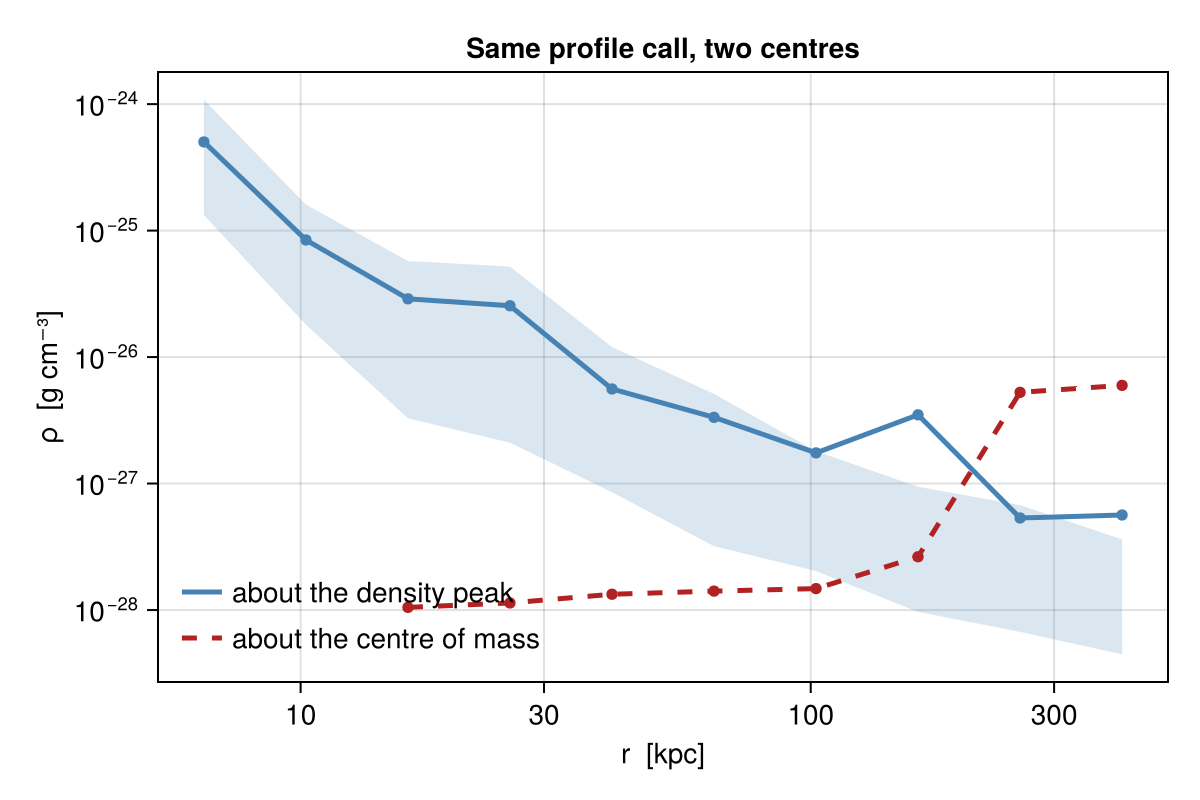

In [ ]:
# --- getmask: the same selection as a BitVector, with no second copy of the data -------
hotmask = getmask(gas, Above(:T, 1e5; unit=:K))
println("getmask  -> ", typeof(hotmask), "  ", count(hotmask), " of ", length(hotmask), " cells")
println("same cells as filterdata: ", count(hotmask) == length(hot.data))

# --- wstat: mean, median, spread and shape in one weighted pass -----------------------
T = getvar(gas, :T, :K); m = getvar(gas, :mass, :Msol); V = getvar(gas, :volume)
sm = wstat(T, m)                    # mass-weighted
sv = wstat(T, V)                    # volume-weighted
sh = wstat(T, m, mask=hotmask)      # mass-weighted, hot gas only
println("⟨T⟩ mass-wtd   ", round(sm.mean, sigdigits=5), " K   median ",
        round(sm.median, sigdigits=5), " K   std ", round(sm.std, sigdigits=5))
println("⟨T⟩ volume-wtd ", round(sv.mean, sigdigits=5), " K")
println("⟨T⟩ hot only   ", round(sh.mean, sigdigits=5), " K")

# --- profile: the centre you choose decides the answer --------------------------------
rho  = getvar(gas, :rho, :g_cm3); ix = argmax(rho)
peak = [getvar(gas,:x,:kpc)[ix], getvar(gas,:y,:kpc)[ix], getvar(gas,:z,:kpc)[ix]]
println("density peak   [kpc] ", round.(peak, digits=1))
println("centre of mass [kpc] ", round.(c, digits=1), "  → ",
        round(sqrt(sum((peak .- c).^2)), digits=0), " kpc apart")

pk = profile(gas, :r_sphere, :rho; center=peak, center_unit=:kpc,
             xunit=:kpc, unit=:g_cm3, xrange=[5.,500.], nbins=10, scale=:log)
cm = profile(gas, :r_sphere, :rho; center=c,    center_unit=:kpc,
             xunit=:kpc, unit=:g_cm3, xrange=[5.,500.], nbins=10, scale=:log)
println("about the peak: inner bin holds ", pk.count[1], " cells")
println("about the COM : inner bin holds ", cm.count[1], " cells")

fig = Figure(size=(600,400))
ax  = Axis(fig[1,1], xscale=log10, yscale=log10, xlabel="r  [kpc]", ylabel="ρ  [g cm⁻³]",
           title="Same profile call, two centres", xticks=([10,30,100,300],["10","30","100","300"]))
band!(ax, pk.x, pk.quantiles[:,1], pk.quantiles[:,3], color=(:steelblue,0.20))
lines!(ax, pk.x, pk.mean, color=:steelblue, linewidth=2.5, label="about the density peak")
scatter!(ax, pk.x, pk.mean, color=:steelblue, markersize=8)
lines!(ax, cm.x, cm.mean, color=:firebrick, linewidth=2.5, linestyle=:dash,
       label="about the centre of mass")
scatter!(ax, cm.x, cm.mean, color=:firebrick, markersize=8)
axislegend(ax, position=:lb, framevisible=false)
fig

### What does not carry over

`slice` and `covering_grid` are grid operations: they need a mesh with a level or index structure
to cut along or sample onto. A Voronoi tessellation has neither — its cells are polyhedra of
arbitrary shape and position — so these raise a `MethodError` rather than a Mera-level refusal.
For a plane through AREPO gas, project a thin slab instead (`zrange` a few cell sizes deep).

`timeseries` needs to enumerate a run's outputs, and it recognises RAMSES, PLUTO, Athena++, FLASH
and Chombo numbering — not AREPO `snapdir_NNN`. That is a discovery gap, not a data-model one, so
the way around it is a one-time conversion: `savedata` each snapshot to a mera file and the whole
series machinery (`timeseries`, `getmovie`, `profiletimeseries`) applies unchanged. A cosmological
run also picks up `redshift` and `aexp` columns automatically.

> **Makie name clashes.** `Sphere` above and `timeseries` here are both exported by Makie as well
> as Mera, so once `CairoMakie` is loaded the bare names are ambiguous. Qualify them
> (`Mera.Sphere`, `Mera.timeseries`) — the error names the conflict, but it is easier to avoid.

In [ ]:
# `timeseries` discovers RAMSES / PLUTO / Athena / FLASH / Chombo output numbering — not
# AREPO snapdirs. Convert once, and the whole series machinery applies unchanged.
# NB Mera.timeseries: like `Sphere`, this name is also exported by Makie.
tsdir = mktempdir()
savedata(gas, tsdir, :write, verbose=false)
ts = Mera.timeseries(tsdir, d -> (mass = msum(d, :Msol),);
                     datatype=:particles, mera_files=true, verbose=false)
show(stdout, ts)

Table with 1 rows, 5 columns:
output  time     redshift  aexp      mass
───────────────────────────────────────────────
24      2056.82  3.99609   0.200156  3.34648e14

## Self-gravity, chemistry & radiative transfer

Where a code writes these fields, the reader maps them to **canonical names** — so the same
`getvar` call works across codes: `:gpot` (potential), `:xHI`/`:xH2`/`:xCO` (chemistry species),
`:Np1…:Np8` (radiation photon groups).

In [17]:
sg = gethydro(getinfo(2, joinpath(base, "ATHENA/athena_selfgravity"), verbose=false), verbose=false)
ch = gethydro(getinfo(5, joinpath(base, "ATHENA/athena_chemistry"),  verbose=false), verbose=false)
rt = gethydro(getinfo(5, joinpath(base, "ATHENA/athena_sixray"),     verbose=false), verbose=false)
(gpot = extrema(getvar(sg, :gpot)),
 xH2  = maximum(getvar(ch, :xH2)),                   # H2 fraction (PDR chemistry)
 Np1  = extrema(getvar(rt, :Np1)))                   # UV radiation field, attenuated by shielding

(gpot = (-0.03948165848851204, 0.0446300245821476), xH2 = 0.4545285999774933, Np1 = (2.655466318130493, 7.641556739807129))

## Convert any code to a Mera file

`savedata`/`loaddata` round-trips **any** loaded object to Mera's portable JLD2 format — so a saved
series even feeds `timeseries(…; mera_files=true)`.

In [18]:
tmp = mktempdir()
savedata(ga, tmp; fmode=:write, verbose=false)
g2 = loaddata(5, tmp, :hydro; verbose=false)
length(g2.data) == length(ga.data) && getvar(g2, :rho) == getvar(ga, :rho)

true

---
Every call above is identical to what you'd run on a RAMSES snapshot — that is the whole point of
the code-blind analysis layer. For per-code details (units, variable mapping, coordinate
conventions, reference readers) see the
[Other Simulation Codes](https://manuelbehrendt.github.io/Mera.jl/stable/multicode/) docs.